# VMD Analysis for Colon Pressure Signal

This notebook performs Variational Mode Decomposition (VMD) on a colon pressure signal.

Steps:
1. Load signal data
2. Apply VMD
3. Plot original signal
4. Plot each decomposed mode
5. Plot reconstructed signal

Sampling frequency: 0.83 Hz

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

# -------------------------- 1. 全局配置（解决字体问题） --------------------------
# 强制使用ASCII减号，禁用Unicode减号
plt.rcParams['axes.unicode_minus'] = False
# 配置中文字体（如需中文标注）
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']
# 忽略无关警告
warnings.filterwarnings("ignore", category=UserWarning, message="Glyph 8722")

## Load Data
Replace 'colon_signal.csv' with your file.
The file should contain one column of pressure values.

In [10]:
fs = 0.83
pre_signal = pd.read_csv(r'D:\a_work\课题组实验数据处理\新预处理\新预处理导出数据\2bHT000007_vmd3_colon_PCHIP_pre.csv')
signal = pre_signal['Pressure_Clean'].values
t = np.arange(len(signal)) / fs
print('Signal length:', len(signal))

Signal length: 71400


In [11]:
signal

array([106.374, 106.296, 106.538, ..., 115.227, 113.339, 112.858])

## Plot Original Signal

Text(0.5, 1.0, 'Original Signal')

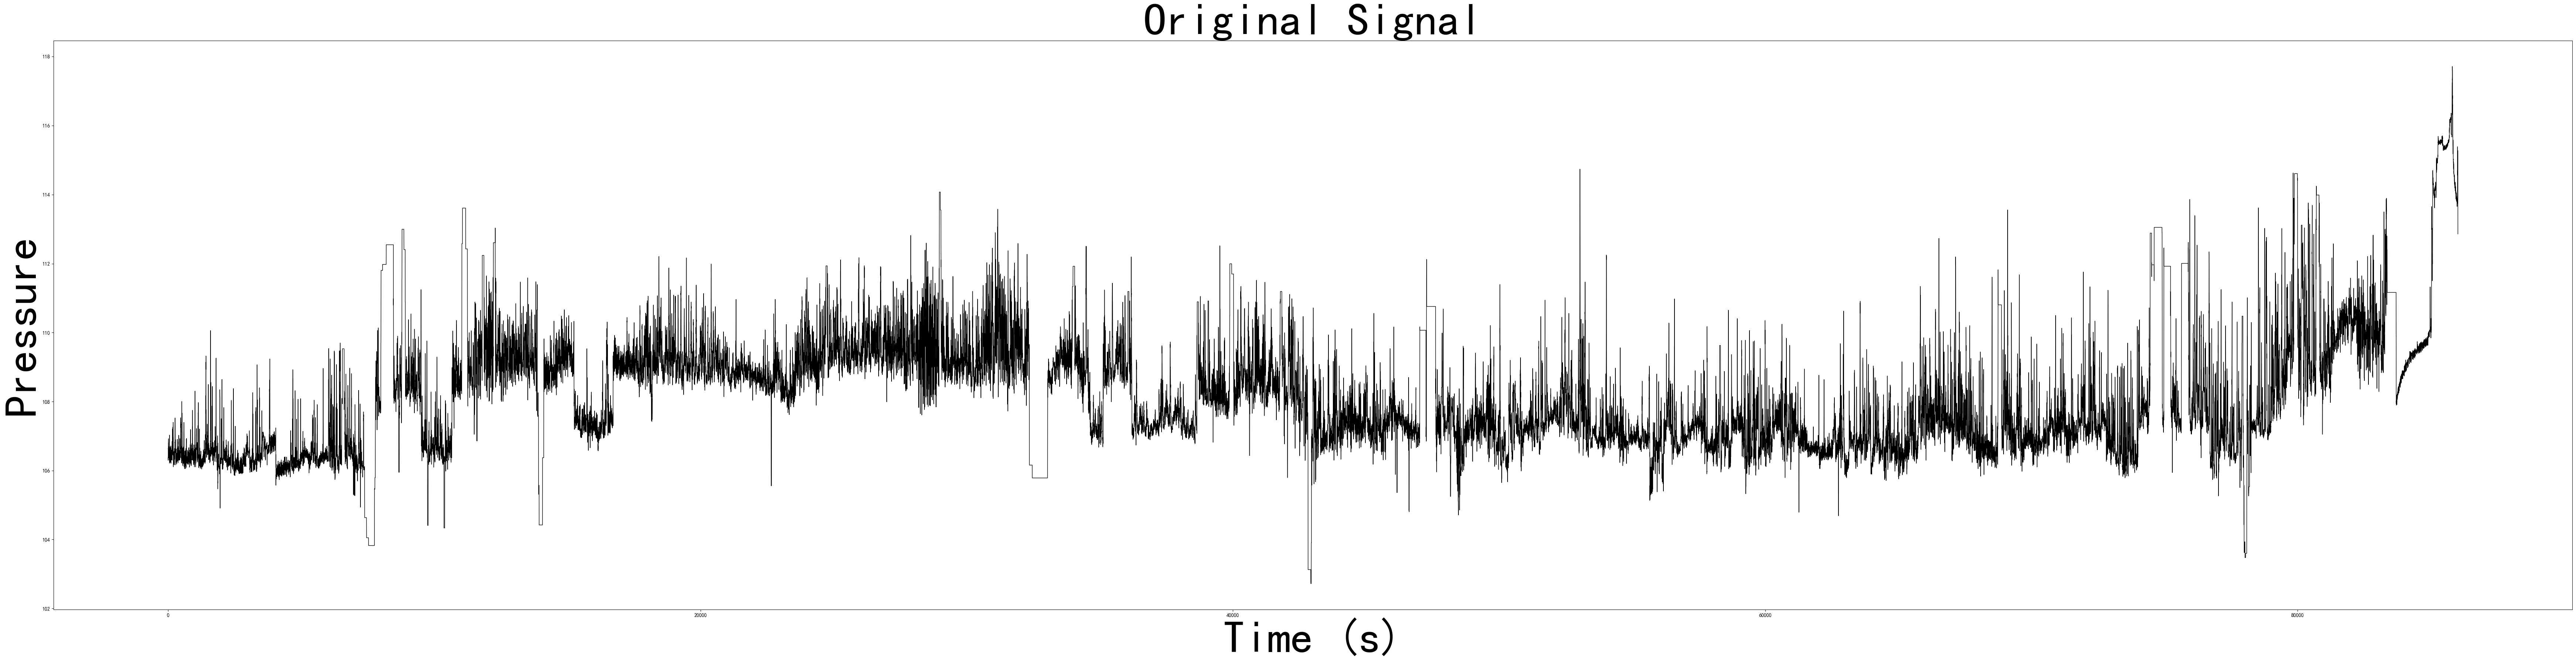

In [12]:

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.figure(figsize=(88, 20))  

# 1. 原始结肠压力信号
plt.plot(t, signal, 'k', linewidth=1)
plt.xlabel('Time (s)', fontsize=88)
plt.ylabel('Pressure', fontsize=88)
plt.title('Original Signal', fontsize=88)

## Run VMD

In [13]:
from vmdpy.vmdpy import VMD
K = 5
alpha = 2500
tau = 0
DC = 1
init = 1
tol = 1e-7

u, u_hat, omega=VMD(signal, alpha, tau, K, DC, init, tol)


## Plot Each Mode

各模态中心频率 (Hz): [0.         0.00850511 0.02564744 0.05205452 0.09167749]


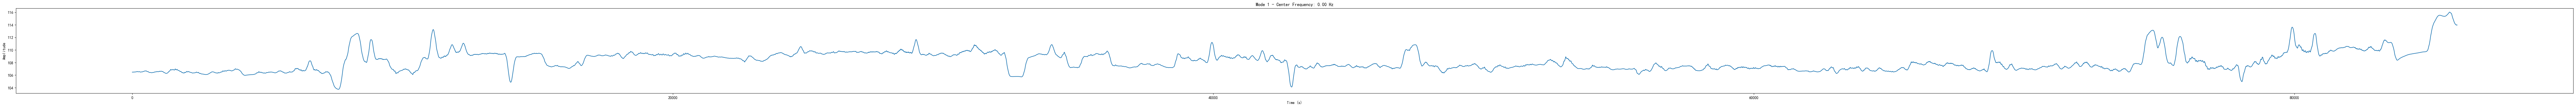

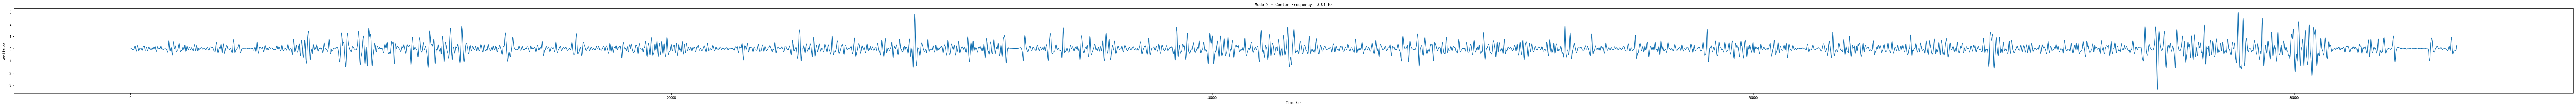

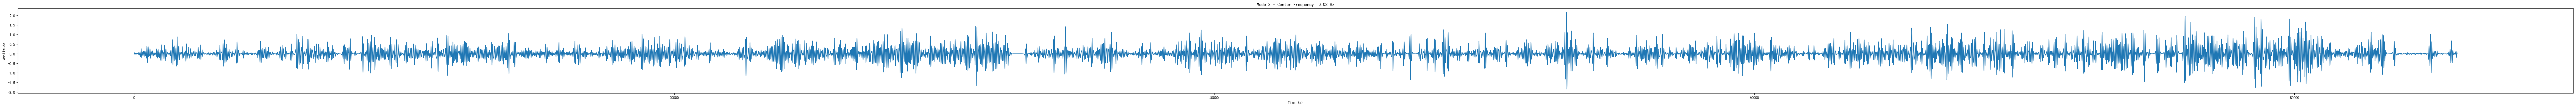

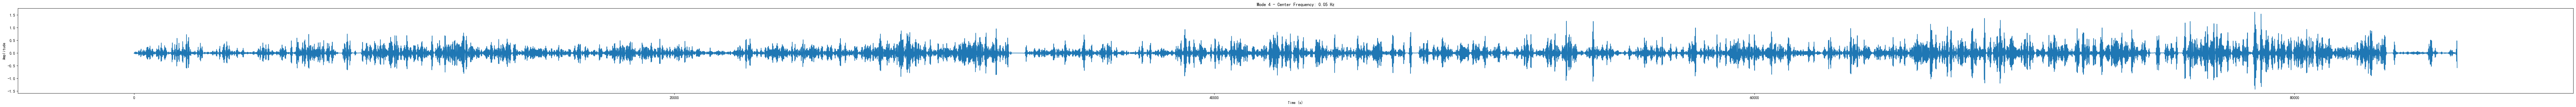

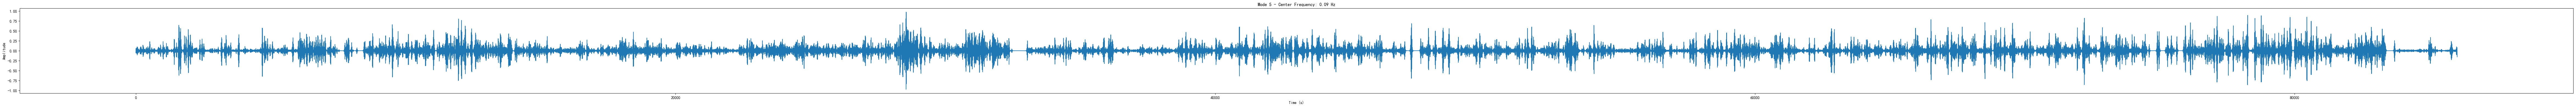

In [14]:

# 查看各模态的中心频率（最后一次迭代结果）
print("各模态中心频率 (Hz):", omega[-1])

# 绘制各模态
fs = 0.83  
t = np.arange(u.shape[1]) / fs

for i in range(u.shape[0]):
    plt.figure(figsize=(120, 4))
    plt.plot(t, u[i])
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude')
    plt.title(f'Mode {i+1} - Center Frequency: {omega[-1][i]:.2f} Hz')
    plt.show()

全模态相关性: 0.994011


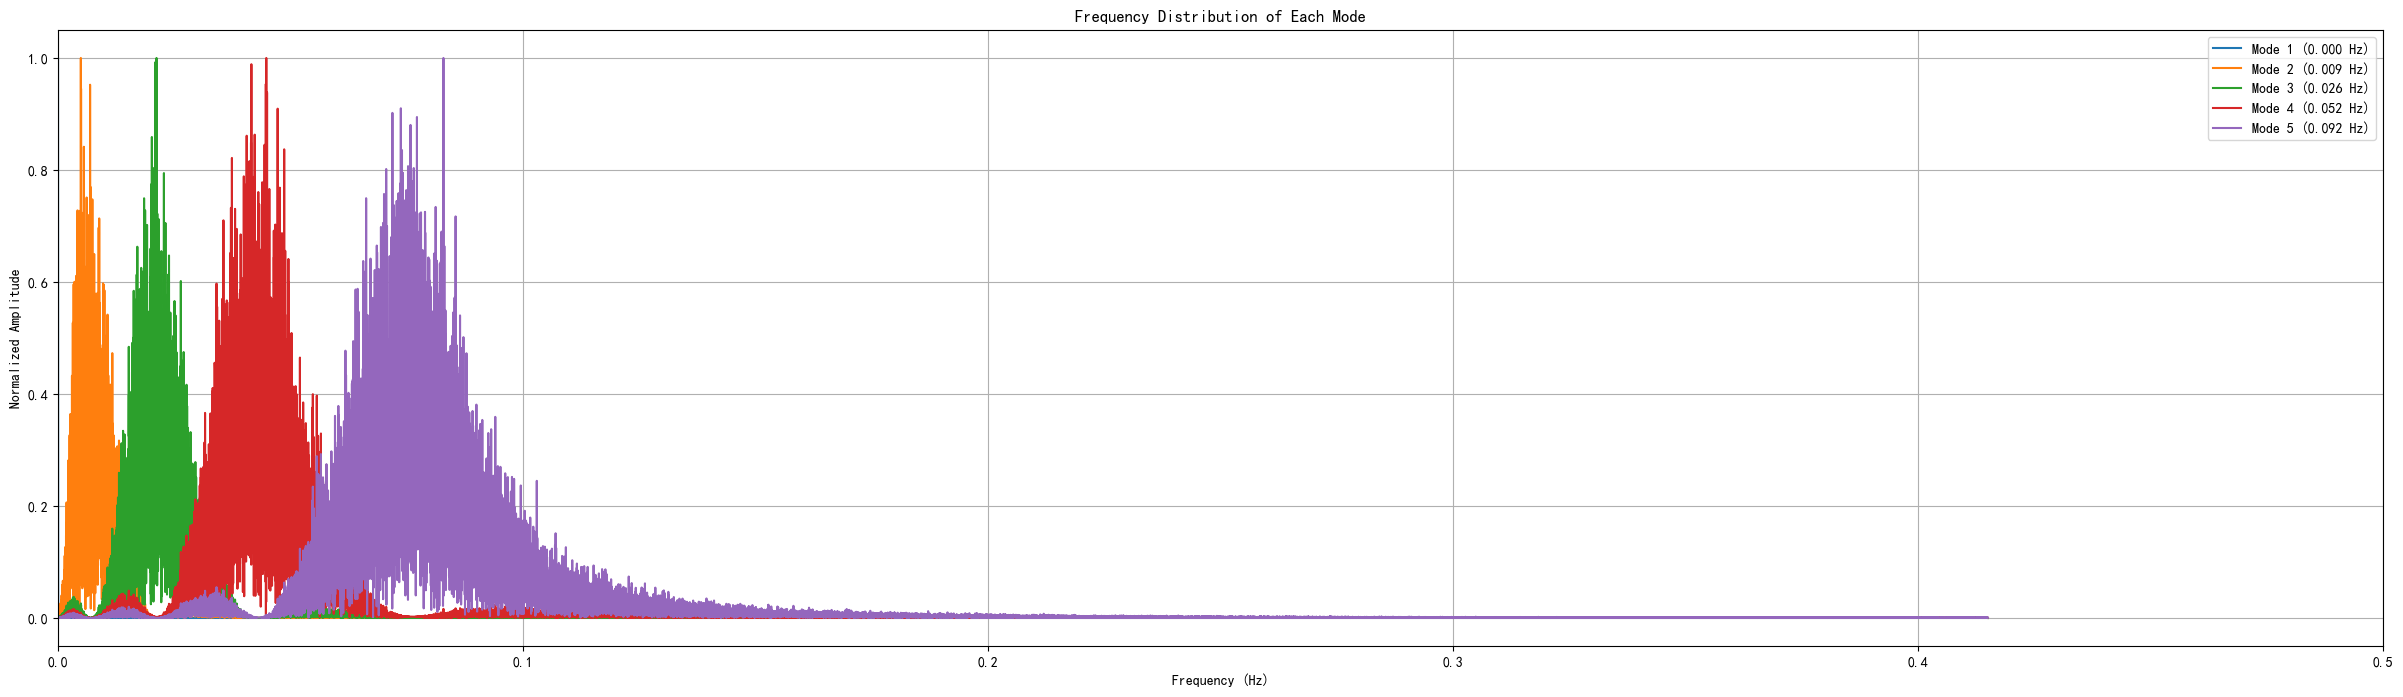

In [15]:
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq

# 验证全模态重构（应该接近100%）
# 全模态重构
signal_all = np.sum(u, axis=0)  
signal_aligned = signal[:signal_all.shape[0]]
corr_full = np.corrcoef(signal_aligned, signal_all)[0,1]
print(f"全模态相关性: {corr_full:.6f}")

fs = 0.83  
n = len(u[0])
freqs = fftfreq(n, 1/fs)

plt.figure(figsize=(30, 8))
for i in range(u.shape[0]):
    spec = np.abs(fft(u[i]))[:n//2]
    plt.plot(freqs[:n//2], spec / np.max(spec), label=f'Mode {i+1} ({omega[-1][i]:.3f} Hz)')

plt.xlabel('Frequency (Hz)')
plt.ylabel('Normalized Amplitude')
plt.title('Frequency Distribution of Each Mode')
plt.legend()
plt.xlim(0, 0.5)  # 结肠信号通常在低频范围
plt.grid(True)
plt.show()

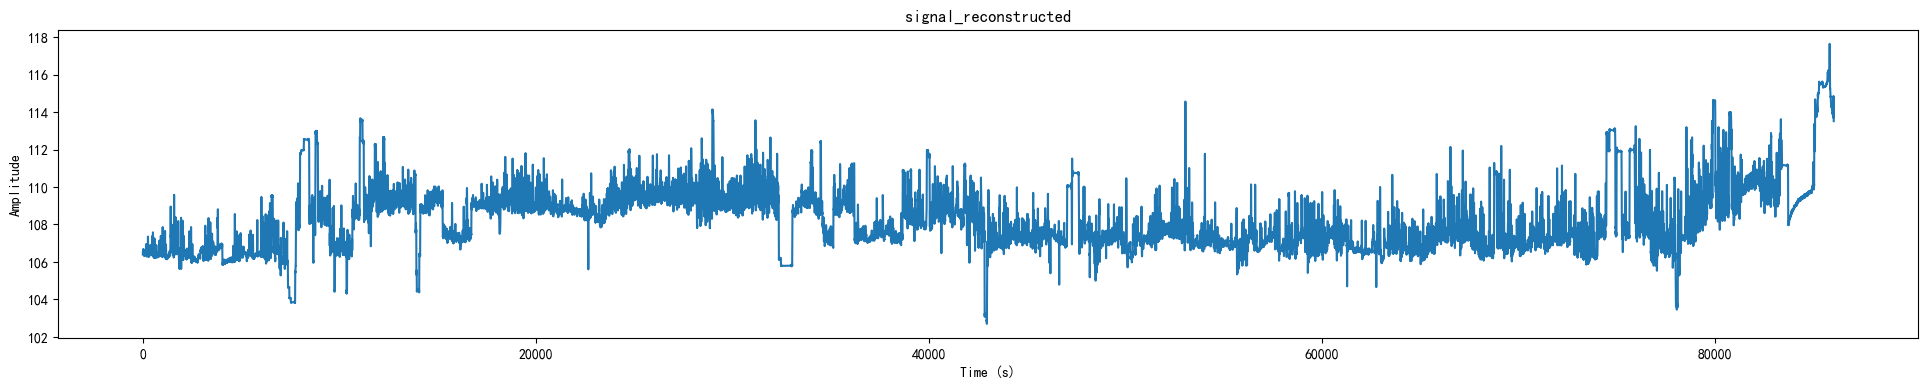

SNR: 19.20 dB
RMSE: 0.192611
Pearsonr: 0.9940
R_squared: 0.9880


In [16]:
# 计算评价的指标
import numpy as np
from scipy.stats import pearsonr

signal_reconstructed = u[1]+u[2] +u[3] + u[0] +u[4]
plt.figure(figsize=(24, 4))
plt.plot(t, signal_reconstructed)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title(f'signal_reconstructed')
plt.show()

# 确保信号长度与重构信号一致
signal_aligned = signal[:signal_reconstructed.shape[0]]

# 1. SNR（信噪比）
def calculate_snr(original, denoised):
    noise = original - denoised
    return 20 * np.log10(np.std(original) / (np.std(noise) + 1e-10))

# 2. RMSE（均方根误差）
def calculate_rmse(original, denoised):
    return np.sqrt(np.mean((original - denoised)**2))

# 3. Pearson相关系数
def calculate_correlation(original, denoised):
    return pearsonr(original, denoised)[0]

# 4. R-squared（决定系数）
def calculate_r2(original, denoised):
    ss_res = np.sum((original - denoised)**2)
    ss_tot = np.sum((original - np.mean(original))**2)
    return 1 - (ss_res / (ss_tot + 1e-10))

SNR = calculate_snr(signal_aligned, signal_reconstructed)
RMSE = calculate_rmse(signal_aligned, signal_reconstructed)
Pearsonr = calculate_correlation(signal_aligned, signal_reconstructed)
R_squared = calculate_r2(signal_aligned, signal_reconstructed)

print(f"SNR: {SNR:.2f} dB")
print(f"RMSE: {RMSE:.6f}")
print(f"Pearsonr: {Pearsonr:.4f}")
print(f"R_squared: {R_squared:.4f}")